In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc3 as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

# Create a center only gabor

(-0.5, 49.5, 49.5, -0.5)

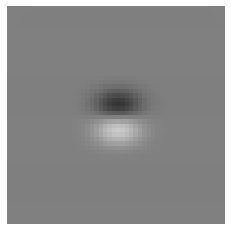

In [2]:
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [15], # 4x std
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : [[25, 25]],
    "orientations"        : [np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

center = GaborSet(**gabor_params)

plt.imshow(center.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

# Create surround gabors (filters)

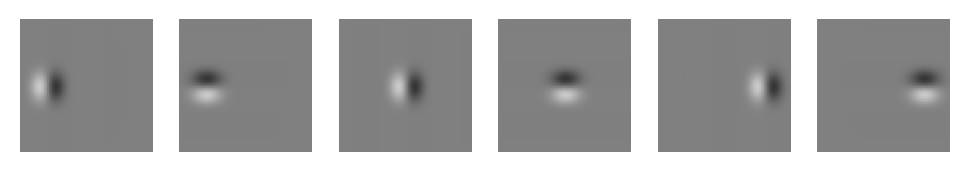

In [16]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [15],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : gabor_locations,
    "orientations"        : [0, np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}


gabor_set = GaborSet(**gabor_params)

fig, axs = plt.subplots(nrows=1, ncols=6, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = gabor_set.images()[idx]
    ax.imshow(gabor, cmap='gray', vmin=-1, vmax=1)
    ax.axis("off")

# Create circle-cut center-gabor

(-0.5, 49.5, 49.5, -0.5)

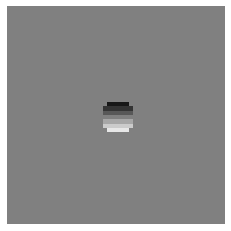

In [17]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0],
}

center_cut = CenterSurround(**center_surround_params)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

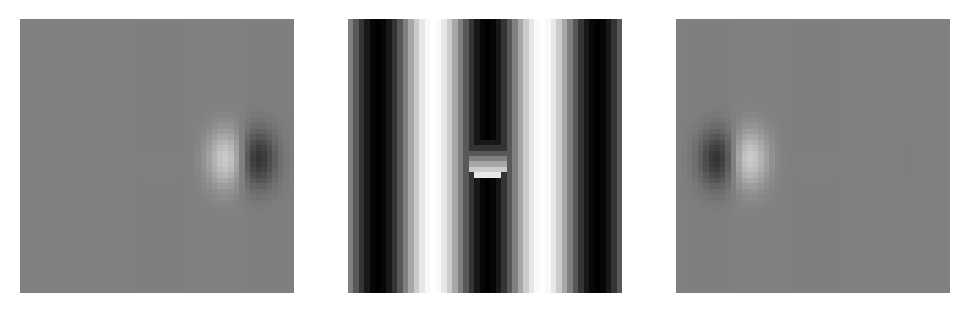

In [25]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-40)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask_right = np.exp(-np.sum((XX - np.array([40, 25]))**2, axis=-1) / (15/4)**2 / 2)
gauss_mask_left = np.exp(-np.sum((XX - np.array([10, 25]))**2, axis=-1) / (15/4)**2 / 2)

fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
axs[0].imshow(center_cut.images()[0]*gauss_mask_right, cmap="gray", vmin=-1, vmax=1)
axs[0].axis("off")
axs[1].imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
axs[1].axis("off")
axs[2].imshow(center_cut.images()[0]*gauss_mask_left, cmap="gray", vmin=-1, vmax=1)
axs[2].axis("off")
# plt.imshow(center_cut.images()[0] * gauss_mask, cmap="gray", vmin=-1, vmax=1)
# plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)

plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

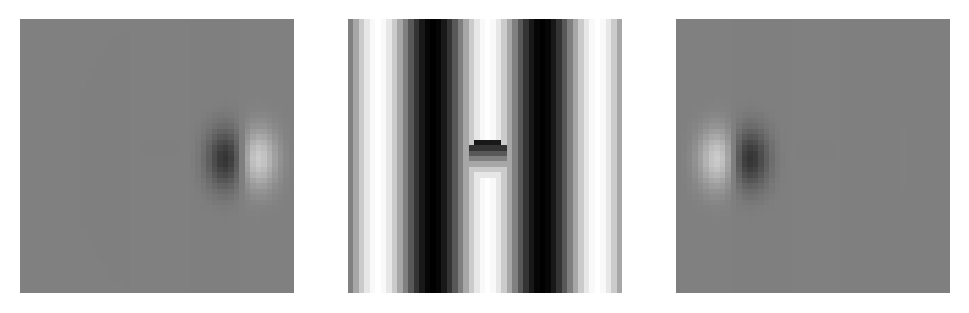

In [27]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask_right = np.exp(-np.sum((XX - np.array([40, 25]))**2, axis=-1) / (15/4)**2 / 2)
gauss_mask_left = np.exp(-np.sum((XX - np.array([10, 25]))**2, axis=-1) / (15/4)**2 / 2)

fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
axs[0].imshow(center_cut.images()[0]*gauss_mask_right, cmap="gray", vmin=-1, vmax=1)
axs[0].axis("off")
axs[1].imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
axs[1].axis("off")
axs[2].imshow(center_cut.images()[0]*gauss_mask_left, cmap="gray", vmin=-1, vmax=1)
axs[2].axis("off")
# plt.imshow(center_cut.images()[0] * gauss_mask, cmap="gray", vmin=-1, vmax=1)
# plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)

plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

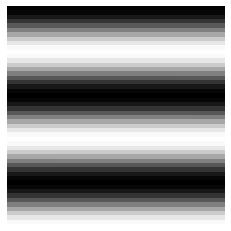

In [29]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": gabor_params["phases"],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [np.pi/2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [ ]:
stimuli = 